In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)

(1470, 35)


In [4]:
cols_to_drop = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18']
df = df.drop(columns=cols_to_drop)
print(df.shape)

(1470, 31)


In [5]:
x = df.drop(columns=['Attrition'])
y = df['Attrition'].map({'Yes': 1, 'No': 0})

print('X shape: ', x.shape)
print('y shape: ', y.shape) 

X shape:  (1470, 30)
y shape:  (1470,)


In [7]:
le = LabelEncoder()
txt_cols = x.select_dtypes(include="object").columns
print('The categorical columns are: ', txt_cols.tolist())

for col in txt_cols:
    x[col]= le.fit_transform(x[col])


The categorical columns are:  ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


C:\Users\Vishal Rathod\AppData\Local\Temp\ipykernel_21716\394687217.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  txt_cols = x.select_dtypes(include="object").columns


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 , stratify=y)
print('X_train shape: ', x_train.shape)
print('y_train shape: ', y_train.shape) 

X_train shape:  (1176, 30)
y_train shape:  (1176,)


In [10]:
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)
print('X_train shape after scaling: ', x_train.shape)
print('X_test shape after scaling: ', x_test.shape)

X_train shape after scaling:  (1176, 30)
X_test shape after scaling:  (294, 30)


In [11]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42 , max_iter=1000)
lr.fit(x_train, y_train)
print('Logistic Regression model trained successfully!')

Logistic Regression model trained successfully!


In [12]:
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score
y_predict = lr.predict(x_test)
print("Logistic Regression  results: ")
print(classification_report(y_test, y_predict))
print("Roc AUC Score: ", roc_auc_score(y_test, y_predict))

Logistic Regression  results: 
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294

Roc AUC Score:  0.675295029718322


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

print("Random Forest trained!")

Random Forest trained!


In [17]:
y_pred_rf = rf_model.predict(x_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.13      0.20        47

    accuracy                           0.84       294
   macro avg       0.68      0.55      0.56       294
weighted avg       0.80      0.84      0.80       294

ROC-AUC Score: 0.5516840382461883


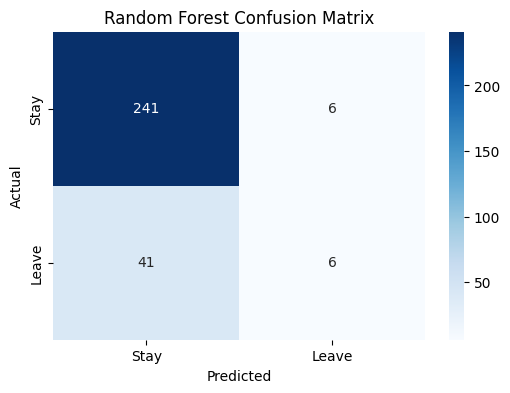

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'],
            yticklabels=['Stay', 'Leave'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

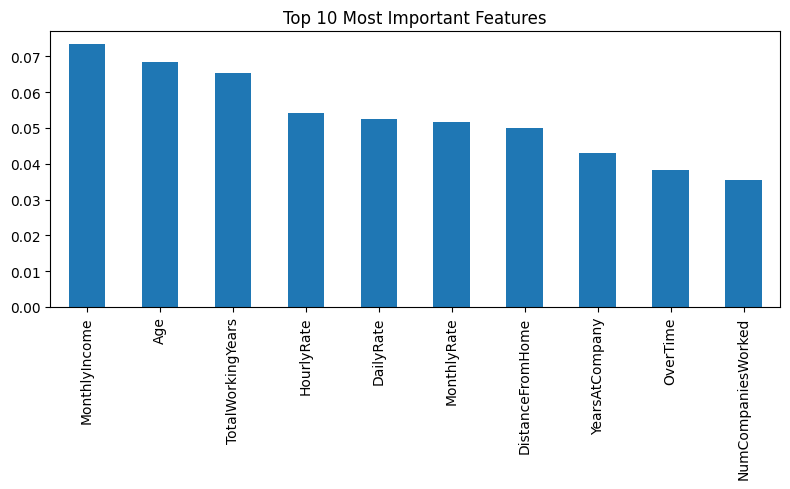

In [19]:
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=df.drop(columns=['Attrition']).columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
feat_importance.plot(kind='bar')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

In [20]:
# Fixed Logistic Regression
lr_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
lr_balanced.fit(x_train, y_train)
y_pred_lr_balanced = lr_balanced.predict(x_test)
print("=== Balanced Logistic Regression ===")
print(classification_report(y_test, y_pred_lr_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr_balanced))

=== Balanced Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.75      0.84       247
           1       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294

ROC-AUC: 0.7574726505297614


In [24]:
# Fixed Random Forest
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_balanced.fit(x_train, y_train)
y_pred_rf_balanced = rf_balanced.predict(x_test)
print("=== Balanced Random Forest ===")
print(classification_report(y_test, y_pred_rf_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_balanced))



=== Balanced Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

ROC-AUC: 0.5324317339994831
